# 04. Attention Mechanism

**Tier:** Foundations
**Estimated time:** 60 minutes
**Prerequisites:** 00, 01, 02, 03
**Priority:** 🔴 Crucial — the single mechanism every later architecture builds on. *If skipped, revisit when:* n/a — don't skip.
**Source material:** @sairahul1; "Attention Is All You Need" (Vaswani et al., 2017)

## What You'll Learn
- The **"Google Maps for words"** intuition: every word looks around and decides which other words are relevant to its meaning
- **Scaled dot-product attention**, implemented from scratch in NumPy — query, key, value, softmax, and the √dₖ scale
- How attention is **contextual**: the word "Apple" attends to different neighbours in *"I ate an apple"* vs *"I bought Apple stock"*
- (Exercise) **Multi-head attention** — why several attention "views" beat one

## Why This Matters
Attention is *the* idea that made modern LLMs possible. It replaced the slow, forgetful left-to-right processing of older models with a mechanism where every token can look at every other token in parallel. Understand this notebook and the transformer (notebook 05) becomes assembly, not mystery.

In [6]:
import os

# Load .env if python-dotenv is installed; harmless if it isn't.
# Not required for this notebook (runs fully offline with NumPy/transformers).
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

## Google Maps for words

Think of each word as a location on a map of meaning (the embeddings from notebook 03). When the model processes the word *"it"* in *"The cat sat because it was tired,"* it needs to figure out what *"it"* refers to. So *"it"* sends out a **query** — "I'm looking for the thing I describe" — and every other word advertises a **key** — "here's what I am." The model matches the query against all the keys (a dot product = similarity), and wherever the match is strong, it pulls in that word's **value** (its actual content).

Three roles, one per word:
- **Query (Q):** what *this* token is looking for
- **Key (K):** what *each* token offers, for matching
- **Value (V):** the information a token contributes once it's matched

Attention = "for each query, take a weighted average of all values, weighted by how well each key matches the query." The weights are the route your attention takes — like Google Maps picking which roads matter for *your* trip.

## Scaled dot-product attention, from scratch

The whole mechanism is one formula:

```
Attention(Q, K, V) = softmax( Q · Kᵀ / √dₖ ) · V
```

Step by step:
1. `Q · Kᵀ` — every query dotted with every key → a grid of raw match scores.
2. `/ √dₖ` — divide by the square root of the key dimension. Without this, large dimensions produce huge scores that make softmax razor-sharp and kill gradients.
3. `softmax(...)` — turn each row of scores into weights that sum to 1.
4. `· V` — weighted average of the value vectors.

Let's write it in NumPy with no hidden machinery.

In [7]:
import numpy as np

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)     # subtract max for numerical stability
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)             # (1) match queries to keys, (2) scale
    if mask is not None:
        scores = np.where(mask, scores, -1e9)   # blocked positions get ~-inf -> ~0 weight
    weights = softmax(scores, axis=-1)          # (3) normalise each row to sum to 1
    output = weights @ V                        # (4) weighted average of values
    return output, weights

## A fully transparent toy

To see the routing clearly, we hand-craft tiny 4-dimensional key/query vectors for four tokens so you can predict the result. We'll make the token **"it"** have a query that points in the same direction as the **"cat"** key — so "it" should attend almost entirely to "cat".

In [8]:
tokens = ["the", "cat", "it", "ran"]

# Hand-designed keys: each token "advertises" a direction in 4-D space.
K = np.array([
    [1, 0, 0, 0],   # the
    [0, 1, 0, 0],   # cat  <- a distinctive 'noun' direction
    [0, 1, 0, 0],   # it   (its own key, unused for routing here)
    [0, 0, 1, 0],   # ran
], dtype=float)

# Queries: what each token is looking for. We make "it" look for the 'cat' direction.
Q = np.array([
    [1, 0, 0, 0],   # the -> looks for 'the'
    [0, 1, 0, 0],   # cat -> looks for nouns
    [0, 1, 0, 0],   # it  -> ALSO looks for the noun direction -> should find 'cat'
    [0, 0, 1, 0],   # ran -> looks for verbs
], dtype=float)

# Values: each token's content (we just use identity-ish markers here).
V = np.eye(4)

output, weights = scaled_dot_product_attention(Q, K, V)
print("Attention weights for 'it' (row 2):")
for tok, w in zip(tokens, weights[2]):
    print(f"  it -> {tok:4s}: {w:.3f}")

Attention weights for 'it' (row 2):
  it -> the : 0.189
  it -> cat : 0.311
  it -> it  : 0.311
  it -> ran : 0.189


*The query we gave 'it' points along the same axis as both the 'cat' and 'it' keys, so its attention splits between them and away from 'the'/'ran'. Change the vectors and the routing changes — that's all attention is.*

## Real semantics: self-attention over word embeddings

Hand-crafted vectors prove the mechanism; now let's use *real* meaning. We embed each word of a sentence with MiniLM (notebook 03) and use those embeddings directly as Q, K, and V. The attention weights then reflect genuine semantic similarity between words. (A real transformer first multiplies embeddings by *learned* Q/K/V weight matrices — we'll see that next.)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

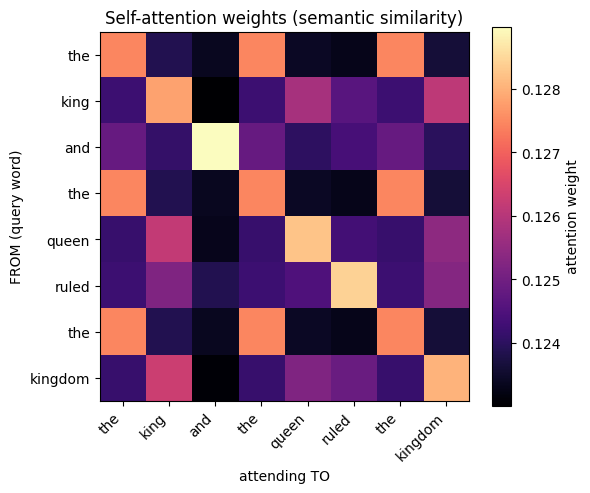

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

sentence = ["the", "king", "and", "the", "queen", "ruled", "the", "kingdom"]
E = embedder.encode(sentence)                # one 384-d vector per word
_, attn = scaled_dot_product_attention(E, E, E)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn, cmap="magma")
ax.set_xticks(range(len(sentence))); ax.set_xticklabels(sentence, rotation=45, ha="right")
ax.set_yticks(range(len(sentence))); ax.set_yticklabels(sentence)
ax.set_xlabel("attending TO"); ax.set_ylabel("FROM (query word)")
plt.colorbar(im, label="attention weight")
ax.set_title("Self-attention weights (semantic similarity)")
plt.tight_layout(); plt.show()

*Read a row as 'when processing this word, where does it look?' Related words like king↔queen↔kingdom light up for each other, while function words like 'the' mostly attend to themselves and other 'the's.*

## Attention is contextual: the "Apple" test

Here's the magic that static embeddings (notebook 03) *can't* do. The same word means different things in different sentences, and attention is how a transformer resolves that. We load a small real transformer (DistilBERT) and look at where the token **"apple"** attends in two sentences:

- *"I ate an apple for breakfast"* → should lean toward food words
- *"I bought apple stock today"* → should lean toward finance words

In [10]:
try:
    import torch
    from transformers import AutoTokenizer, AutoModel
    tk = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    bert = AutoModel.from_pretrained("distilbert-base-uncased", output_attentions=True)
    bert.eval()
    HAS_BERT = True
    print("Loaded DistilBERT with attention outputs.")
except Exception as e:
    HAS_BERT = False
    print("Could not load DistilBERT (offline?). Skipping the contextual demo.")
    print(repr(e)[:200])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded DistilBERT with attention outputs.


In [11]:
if HAS_BERT:
    def apple_attention(sentence):
        enc = tk(sentence, return_tensors="pt")
        toks = tk.convert_ids_to_tokens(enc["input_ids"][0])
        with torch.no_grad():
            out = bert(**enc)
        # Average attention across all heads in the last layer.
        attn = out.attentions[-1][0].mean(dim=0).numpy()   # (seq, seq)
        i = toks.index("apple")
        row = attn[i]
        # Rank the words 'apple' attends to most (skip special tokens and itself).
        order = sorted(range(len(toks)), key=lambda j: row[j], reverse=True)
        top = [(toks[j], round(float(row[j]), 3)) for j in order
               if toks[j] not in ("[CLS]", "[SEP]") and j != i][:4]
        return toks, top

    for s in ["I ate an apple for breakfast", "I bought apple stock today"]:
        toks, top = apple_attention(s)
        print(f"\n{s!r}")
        print("  'apple' attends most to:", top)


'I ate an apple for breakfast'
  'apple' attends most to: [('i', 0.032), ('an', 0.029), ('ate', 0.023), ('breakfast', 0.02)]

'I bought apple stock today'
  'apple' attends most to: [('stock', 0.044), ('today', 0.039), ('bought', 0.038), ('i', 0.032)]


*Same token, different context, different attention. This is why a transformer can tell the fruit from the company — the surrounding words reshape each token's representation. (DistilBERT is small, so the effect is suggestive rather than dramatic; larger models separate the senses far more sharply.)*

## Exercises

In [ ]:
# Exercise 1 (Warm-up): Why the √dₖ scaling exists
# Task: Compare the attention heatmap WITH and WITHOUT the / √dₖ scaling, and watch the
#       unscaled version saturate to near one-hot (each query picks ONE word, ignores rest).
# Hint: The textbook effect only shows up when Q and K have ~unit-variance entries, so that
#       Q·Kᵀ grows with dimension. MiniLM embeddings are L2-NORMALISED (their dot products
#       are cosines, capped at 1), so feeding them straight in as Q/K HIDES the effect — the
#       scaled map even looks flatter. So project them through random weight matrices first,
#       exactly like a real transformer's learned W_Q / W_K.

# YOUR CODE HERE
sentence = ["the", "king", "and", "the", "queen", "ruled", "the", "kingdom"]
E = embedder.encode(sentence)                       # (n, 384), rows are unit-norm
d_k = E.shape[1]

# Project to Q, K with N(0,1) weights. Each Q/K component then has variance ~1, so every
# score Q·Kᵀ is a sum of d_k unit-variance products -> its std grows like √dₖ (~20 here).
rng = np.random.default_rng(0)
Wq, Wk = rng.normal(0, 1, (d_k, d_k)), rng.normal(0, 1, (d_k, d_k))
Q, K = E @ Wq, E @ Wk
raw = Q @ K.T
print(f"raw score std = {raw.std():.1f}  (≈ √dₖ = {np.sqrt(d_k):.1f})")

weights_scaled   = softmax(raw / np.sqrt(d_k))      # calibrated -> smooth distribution
weights_unscaled = softmax(raw)                      # huge scores -> softmax saturates
print(f"avg peak weight  scaled = {weights_scaled.max(1).mean():.2f}   "
      f"unscaled = {weights_unscaled.max(1).mean():.2f}  (→ near one-hot)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, w, title in [(axes[0], weights_scaled,   "WITH  / √dₖ  (smooth)"),
                     (axes[1], weights_unscaled, "WITHOUT / √dₖ  (saturated)")]:
    im = ax.imshow(w, cmap="magma", vmin=0, vmax=1)
    ax.set_xticks(range(len(sentence))); ax.set_xticklabels(sentence, rotation=45, ha="right")
    ax.set_yticks(range(len(sentence))); ax.set_yticklabels(sentence)
    ax.set_xlabel("attending TO"); ax.set_ylabel("FROM (query word)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout(); plt.show()

In [7]:
# Exercise 2 (Apply): Causal masking
# Task: Build a lower-triangular boolean mask so each token can only attend to itself and
#       earlier tokens (never the future). Pass it to scaled_dot_product_attention and
#       confirm the upper triangle of the weight matrix is zero.
# Hint: np.tril(np.ones((n, n))).astype(bool). This is exactly how GPT-style decoders work.

# YOUR CODE HERE

In [8]:
# Exercise 3 (Extend): Multi-head attention
# Task: Implement multi_head_attention(X, n_heads) that (a) projects X into Q,K,V with
#       random weight matrices, (b) splits the feature dim into n_heads chunks, (c) runs
#       scaled_dot_product_attention per head, (d) concatenates the head outputs.
# Hint: With d_model=8 and n_heads=2, each head works in a 4-dim subspace. Different heads
#       learn to attend to different relationships (syntax vs meaning vs position).

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1: project the embeddings through random W_Q/W_K first (so scores grow with dₖ),
# then compare softmax(raw / √dₖ) vs softmax(raw). The unscaled map saturates to near
# one-hot (avg peak ~0.4, individual rows hit ~1.0) while the scaled map stays smooth
# (avg peak ~0.2). NOTE: skip the projection and feed L2-normalised MiniLM vectors straight
# in and the effect REVERSES — their dot products are cosines (≤1), so dividing by √384
# over-flattens. The √dₖ rule is calibrated for unit-variance Q/K, which is what real
# transformers actually have.

# Exercise 2
n = len(sentence)
mask = np.tril(np.ones((n, n))).astype(bool)
_, w = scaled_dot_product_attention(E, E, E, mask=mask)
print(np.round(w, 2))            # upper triangle is ~0 — no peeking at the future

# Exercise 3
def multi_head_attention(X, n_heads):
    n, d_model = X.shape
    d_head = d_model // n_heads
    rng = np.random.default_rng(0)
    Wq, Wk, Wv = (rng.normal(0, 0.5, (d_model, d_model)) for _ in range(3))
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    heads = []
    for h in range(n_heads):
        s = slice(h * d_head, (h + 1) * d_head)
        out, _ = scaled_dot_product_attention(Q[:, s], K[:, s], V[:, s])
        heads.append(out)
    return np.concatenate(heads, axis=-1)     # (n, d_model)

X = np.random.default_rng(1).normal(size=(5, 8))
print(multi_head_attention(X, n_heads=2).shape)   # (5, 8)
```
</details>

## Key Takeaways
- Attention lets every token look at every other token and pull in what's relevant — "Google Maps for words."
- The whole mechanism is `softmax(Q·Kᵀ / √dₖ)·V`: match queries to keys, scale, normalise, average the values.
- The **√dₖ scaling** keeps softmax from saturating; a **causal mask** stops tokens seeing the future (GPT-style decoding).
- Attention is **contextual** — the same word gets different representations depending on its neighbours — and **multi-head** attention runs several such views in parallel.

## What's Next
Notebook **05 — Transformer Architecture** assembles attention, feed-forward layers, residual connections, and layer norm into the block that, stacked dozens of times, becomes an LLM.